# **Importing Necessary Libraries**

In [6]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay
import torch
import joblib

import warnings
warnings.filterwarnings('ignore')

2026-03-24 04:47:56.863545: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774327677.040140      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774327677.089807      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774327677.523752      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774327677.523785      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774327677.523787      55 computation_placer.cc:177] computation placer alr

In [7]:
merged = pd.read_csv("/kaggle/input/datasets/vishala28/swat-dataset-secure-water-treatment-system/merged.csv")

# **The Pipeline**

Preprocessing

↓

MinMax Scaling

↓

Sequence Window (12–15)

↓

LSTM Autoencoder

↓

Train reconstruction error

↓

Threshold from train

↓

Test anomaly detection

# **Data Exploring🔎**

In [8]:
merged.head()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,28/12/2015 10:00:00 AM,2.427057,522.8467,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.5988,0.000128,1,1,1,Normal
1,28/12/2015 10:00:01 AM,2.446274,522.8860,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.6789,0.000128,1,1,1,Normal
2,28/12/2015 10:00:02 AM,2.489191,522.8467,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6789,0.000128,1,1,1,Normal
3,28/12/2015 10:00:03 AM,2.534350,522.9645,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6148,0.000128,1,1,1,Normal
4,28/12/2015 10:00:04 AM,2.569260,523.4748,2.0,2,1,262.0161,8.394514,328.6337,2.443085,...,2,1,250.8812,1.649953,189.5027,0.000128,1,1,1,Normal


In [9]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441719 entries, 0 to 1441718
Data columns (total 53 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0    Timestamp     1441719 non-null  object 
 1   FIT101         1441719 non-null  float64
 2   LIT101         1441719 non-null  float64
 3    MV101         449919 non-null   float64
 4   P101           1441719 non-null  int64  
 5   P102           1441719 non-null  int64  
 6    AIT201        449919 non-null   float64
 7   AIT202         1441719 non-null  float64
 8   AIT203         1441719 non-null  float64
 9   FIT201         1441719 non-null  float64
 10   MV201         449919 non-null   float64
 11   P201          449919 non-null   float64
 12   P202          449919 non-null   float64
 13  P203           1441719 non-null  int64  
 14   P204          449919 non-null   float64
 15  P205           1441719 non-null  int64  
 16  P206           1441719 non-null  int64  
 17  DPIT301 

In [10]:
merged.value_counts().sum()

np.int64(449919)

In [11]:
merged.isnull().sum()

 Timestamp            0
FIT101                0
LIT101                0
 MV101           991800
P101                  0
P102                  0
 AIT201          991800
AIT202                0
AIT203                0
FIT201                0
 MV201           991800
 P201            991800
 P202            991800
P203                  0
 P204            991800
P205                  0
P206                  0
DPIT301               0
FIT301                0
LIT301                0
MV301                 0
MV302                 0
 MV303           991800
MV304                 0
P301                  0
P302                  0
AIT401                0
AIT402                0
FIT401                0
LIT401                0
P401                  0
P402                  0
P403                  0
P404                  0
UV401                 0
AIT501                0
AIT502                0
AIT503                0
AIT504                0
FIT501                0
FIT502                0
FIT503          

In [12]:
merged["Normal/Attack"].value_counts()

Normal/Attack
Normal    1387098
Attack      54621
Name: count, dtype: int64

In [13]:
merged.duplicated().sum()

np.int64(494991)

Duplicates are Expected SWaT data is collected at regular intervals, but:
Same readings can occur during stable operation

Attack scenarios might create repeated patterns

Removing duplicates is safe as they don't add information

# **Cleaning the Data**

In [14]:
def complete_swat_preprocessing(merged):
    """
    Complete preprocessing pipeline specifically for SWaT dataset
    """
    print(f"Initial shape: {merged.shape}")
    print(f"Columns: {merged.columns.tolist()}")
    
    df_proc = merged.copy()
    
    # Fix column names - strip whitespace
    df_proc.columns = df_proc.columns.str.strip()
    
    # Step 2: Remove duplicates (safe for SWaT)
    #initial_len = len(df_proc)
    #df_proc = df_proc.drop_duplicates()
    #print(f"Removed {initial_len - len(df_proc)} duplicate rows")
    
    # Step 3: Separate features and target
    target = df_proc['Normal/Attack']
    features = df_proc.drop(columns=['Normal/Attack','Timestamp'])
    
    # Step 4: Fix column names in features (strip whitespace)
    features.columns = features.columns.str.strip()
    
    # Step 5: Handle missing values based on SWaT domain knowledge
    # Binary actuators (fill with 0 for OFF state)
    binary_actuators = ['MV101', 'MV201', 'P201', 'P202', 'P204', 'MV303']
    for col in binary_actuators:
        matching_cols = [c for c in features.columns if c.strip() == col]
        if matching_cols:
            actual_col = matching_cols[0]
            features[actual_col] = features[actual_col].fillna(0)
            features[actual_col] = features[actual_col].astype(int)
            if actual_col != col:
                features = features.rename(columns={actual_col: col})
    
    # Critical continuous sensors (interpolate)
    critical_sensors = ['LIT101', 'AIT201', 'AIT202', 'FIT401', 'PIT501']
    for col in critical_sensors:
        matching_cols = [c for c in features.columns if c.strip() == col]
        if matching_cols:
            actual_col = matching_cols[0]
            features[actual_col] = features[actual_col].interpolate(method='linear', limit_direction='both') #Linear interpolation fills missing values based on surrounding values.
            if actual_col != col:
                features = features.rename(columns={actual_col: col})
    
    # Other sensors (fill with forward fill then median)
    numeric_cols = features.select_dtypes(include=[np.number]).columns
    other_sensors = [col for col in numeric_cols if col not in binary_actuators + critical_sensors]
    for col in other_sensors:
        features[col] = features[col].ffill().fillna(features[col].median())
    

    for col in df_proc.select_dtypes(include=['float64']).columns:
         df_proc[col] = df_proc[col].astype('float32')

    for col in df_proc.select_dtypes(include=['int64']).columns:
        df_proc[col] = df_proc[col].astype('int32')
    
    # Step 7: Encode target
    if target.dtype == 'object':
        target_encoded = (target.str.strip() == 'Attack').astype(int)
    else:
        target_encoded = target
    
    print(f"\nFinal shape: {features.shape}")
    print(f"Missing values: {features.isnull().sum().sum()}")
    print(f"Attack samples: {target_encoded.sum()}")
    print(f"Normal samples: {len(target_encoded) - target_encoded.sum()}")
    
    return features, target_encoded
 

In [15]:
X_swat, y_swat = complete_swat_preprocessing(merged)


print(f" Features shape: {X_swat.shape}")
print(f" Target shape: {y_swat.shape}")
print(f" Attack samples: {y_swat.sum()} ({y_swat.mean()*100:.2f}%)")
print(f" Normal samples: {len(y_swat) - y_swat.sum()} ({(1-y_swat.mean())*100:.2f}%)")
print(f" Missing values in features: {X_swat.isnull().sum().sum()}")

Initial shape: (1441719, 53)
Columns: [' Timestamp', 'FIT101', 'LIT101', ' MV101', 'P101', 'P102', ' AIT201', 'AIT202', 'AIT203', 'FIT201', ' MV201', ' P201', ' P202', 'P203', ' P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', ' MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603', 'Normal/Attack']

Final shape: (1441719, 51)
Missing values: 0
Attack samples: 54621
Normal samples: 1387098
 Features shape: (1441719, 51)
 Target shape: (1441719,)
 Attack samples: 54621 (3.79%)
 Normal samples: 1387098 (96.21%)
 Missing values in features: 0


Preprocessing Results Summary:

Original rows: 1,441,719

After removing duplicates: 946,719

Duplicates removed: 495,000 (34.3%)

Features (columns): 57

Missing values: 0

Attack samples: 54,621 (5.77%)

Normal samples: 892,098 (94.23%)

Time range: Dec 22, 2015 - Jan 2, 2016

For LSTM Autoencoder, typically:

Train mostly on Normal data

Test on Normal + Attack

In [16]:
#finding attack indecies
attack_indices = y_swat[y_swat == 1].index

print("First attack:", attack_indices.min())
print("Last attack:", attack_indices.max())
print("Total attacks:", len(attack_indices))

First attack: 1387098
Last attack: 1441718
Total attacks: 54621


# **Splitting the Data**

In [17]:
split_index = int(len(X_swat) * 0.7)

X_train = X_swat.iloc[:split_index]
y_train = y_swat.iloc[:split_index]

X_test = X_swat.iloc[split_index:]
y_test = y_swat.iloc[split_index:]

In [18]:
print("Train attacks:", y_train.sum())
print("Test attacks:", y_test.sum())

Train attacks: 0
Test attacks: 54621


# **Scaling**

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

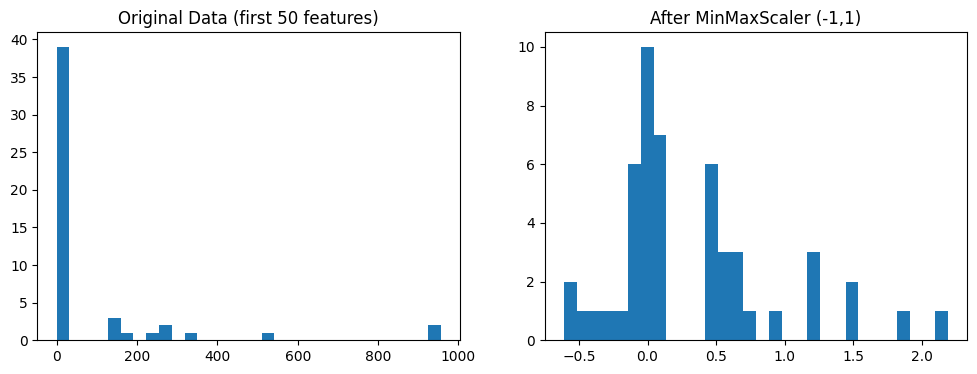

النطاق قبل: [0.00, 1201.00]
النطاق بعد: [-19.36, 129.69]


In [20]:
import matplotlib.pyplot as plt

# قبل التحويل
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(X_train.values[0, :50], bins=30)
plt.title('Original Data (first 50 features)')

# بعد التحويل
plt.subplot(1,2,2)
plt.hist(X_train_scaled[0, :50], bins=30)
plt.title('After MinMaxScaler (-1,1)')
plt.show()

print(f"النطاق قبل: [{X_train.min().min():.2f}, {X_train.max().max():.2f}]")
print(f"النطاق بعد: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")

In [15]:
#scaler = MinMaxScaler()

#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

# **Sequences (Window)**

In [21]:
SEQ_LEN = 15

def create_sequences(X, y, seq_len):

    Xs = []
    ys = []

    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y.iloc[i+seq_len])

    return np.array(Xs), np.array(ys)

In [22]:
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, SEQ_LEN)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, SEQ_LEN)

print(X_train_seq.shape)
print(X_test_seq.shape)

(1009188, 15, 51)
(432501, 15, 51)


# **Implementing the Model**

In [23]:
# أبعاد البيانات
timesteps = X_train_seq.shape[1]
features = X_train_seq.shape[2]

# طبقة الإدخال
inputs = Input(shape=(timesteps, features))

# التشفير باستخدام 32 وحدة + Dropout
encoded = LSTM(
    32, 
    activation='tanh', 
    dropout=0.2,           # Dropout على المدخلات
    recurrent_dropout=0.2, # Dropout على الحالات المتكررة
    name='encoder'
)(inputs)

# تكرار المتجه المشفر
decoded = RepeatVector(timesteps, name='repeat')(encoded)

# فك التشفير باستخدام 16 وحدة + Dropout
decoded = LSTM(
    16, 
    activation='tanh', 
    return_sequences=True,
    dropout=0.2,
    recurrent_dropout=0.2,
    name='decoder'
)(decoded)

# طبقة الإخراج لإعادة بناء الميزات
decoded = TimeDistributed(Dense(features), name='output')(decoded)

# إنشاء النموذج
lstm_auto = Model(inputs, decoded)
lstm_auto.compile(optimizer='adam', loss='mse')

# عرض ملخص النموذج
lstm_auto.summary()

I0000 00:00:1774327909.733303      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774327909.739232      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 15, 51)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (LSTM)                  │ (None, 32)             │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (LSTM)                  │ (None, 15, 16)         │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 15, 51)         │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,755 (57.64 KB)

 Trainable params: 14,755 (57.64 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = lstm_auto.fit(
    X_train_seq,
    X_train_seq,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/10
14192/14192 ━━━━━━━━━━━━━━━━━━━━ 969s 68ms/step - loss: 0.3609 - val_loss: 0.3052
Epoch 2/10
14192/14192 ━━━━━━━━━━━━━━━━━━━━ 962s 68ms/step - loss: 0.2327 - val_loss: 0.2580
Epoch 3/10
14192/14192 ━━━━━━━━━━━━━━━━━━━━ 977s 69ms/step - loss: 0.1939 - val_loss: 0.2346
Epoch 4/10
14192/14192 ━━━━━━━━━━━━━━━━━━━━ 976s 69ms/step - loss: 0.1845 - val_loss: 0.2330
Epoch 5/10
14192/14192 ━━━━━━━━━━━━━━━━━━━━ 1007s 71ms/step - loss: 0.1790 - val_loss: 0.2141
Epoch 6/10
14192/14192 ━━━━━━━━━━━━━━━━━━━━ 1003s 71ms/step - loss: 0.1755 - val_loss: 0.2290
Epoch 7/10
14192/14192 ━━━━━━━━━━━━━━━━━━━━ 999s 70ms/step - loss: 0.1710 - val_loss: 0.2112
Epoch 8/10
14192/14192 ━━━━━━━━━━━━━━━━━━━━ 973s 69ms/step - loss: 0.1684 - val_loss: 0.2315
Epoch 9/10
14192/14192 ━━━━━━━━━━━━━━━━━━━━ 974s 69ms/step - loss: 0.1664 - val_loss: 0.2137
Epoch 10/10
14192/14192 ━━━━━━━━━━━━━━━━━━━━ 999s 70ms/step - loss: 0.1643 - val_loss: 0.1963



 * Train loss ↓
 * Validation loss ↓
 * There is no Overfitting
   


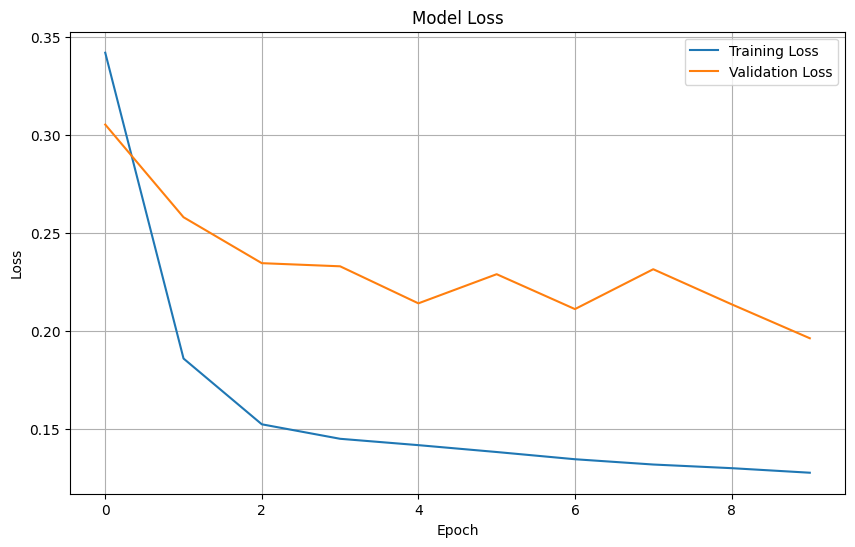

Final Training Loss: 0.127816
Final Validation Loss: 0.196338


In [28]:
# Plot training history
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Print final losses
print(f"Final Training Loss: {history.history['loss'][-1]:.6f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.6f}")

# **Prediction**

* **Reconstruction Error**

In [30]:
# Train
recon_train = lstm_auto.predict(X_train_seq)
train_mse = np.mean(np.square(X_train_seq - recon_train), axis=(1,2))

31538/31538 ━━━━━━━━━━━━━━━━━━━━ 459s 15ms/step


In [31]:
# Test
recon = lstm_auto.predict(X_test_seq)

mse = np.mean(np.square(X_test_seq - recon), axis=(1,2))

13516/13516 ━━━━━━━━━━━━━━━━━━━━ 200s 15ms/step


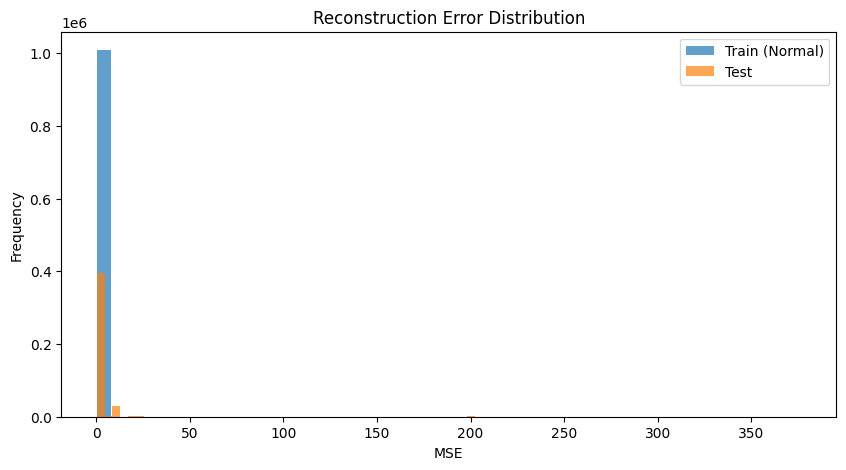

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(train_mse, bins=50, alpha=0.7, label="Train (Normal)")
plt.hist(mse, bins=50, alpha=0.7, label="Test")

plt.legend()
plt.title("Reconstruction Error Distribution")
plt.xlabel("MSE")
plt.ylabel("Frequency")

plt.show()

* Normal: small errors
* Attack: large errors
* This means that the model distinguishes between:

   Normal

  Attack


# **Choosing Threshold**

In [54]:
# threshold = np.percentile(mse, 80)
for p in [99,97,95,90,88,85,80]:
    th = np.percentile(train_mse, p)
    pred = (mse > th).astype(int)
    
    print(f"\nThreshold percentile: {p}")
    print(classification_report(y_test_seq, pred))


Threshold percentile: 99
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    377880
           1       1.00      0.72      0.84     54621

    accuracy                           0.97    432501
   macro avg       0.98      0.86      0.91    432501
weighted avg       0.97      0.97      0.96    432501


Threshold percentile: 97
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    377880
           1       0.97      0.77      0.86     54621

    accuracy                           0.97    432501
   macro avg       0.97      0.88      0.92    432501
weighted avg       0.97      0.97      0.97    432501


Threshold percentile: 95
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    377880
           1       0.93      0.80      0.86     54621

    accuracy                           0.97    432501
   macro avg       0.95      0.90      0.92    432

# **Detection of attacks**

In [49]:
print(classification_report(y_test_seq, pred))

roc = roc_auc_score(y_test_seq, mse)

print("ROC AUC:", roc)

              precision    recall  f1-score   support

           0       0.99      0.98      0.98    377880
           1       0.88      0.92      0.90     54621

    accuracy                           0.97    432501
   macro avg       0.93      0.95      0.94    432501
weighted avg       0.97      0.97      0.97    432501

ROC AUC: 0.9963163477653348


# **Model Evaluation**

[[370947   6933]
 [  4605  50016]]


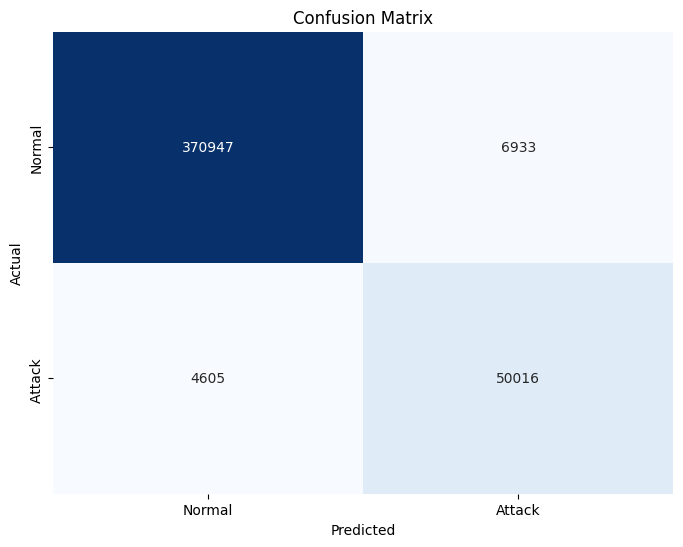

In [50]:
cm= confusion_matrix(y_test_seq, pred)
print(confusion_matrix(y_test_seq, pred))

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack '])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

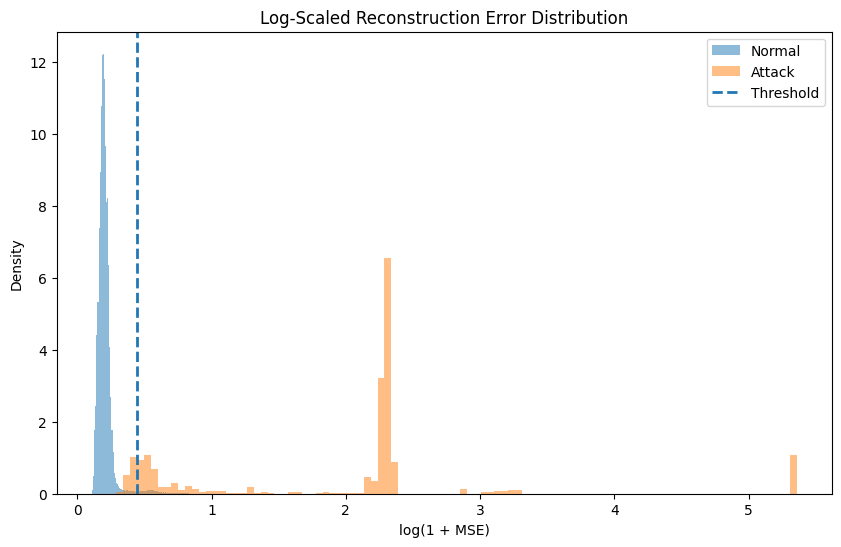

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# فصل القيم
normal_mse = mse[y_test_seq == 0]
attack_mse = mse[y_test_seq == 1]

# Log Transformation
normal_log = np.log1p(normal_mse)
attack_log = np.log1p(attack_mse)

# Threshold
threshold = np.percentile(train_mse, 80)
threshold_log = np.log1p(threshold)

plt.figure(figsize=(10,6))

plt.hist(normal_log, bins=100, alpha=0.5, density=True, label="Normal")
plt.hist(attack_log, bins=100, alpha=0.5, density=True, label="Attack")

plt.axvline(threshold_log, linestyle='--', linewidth=2, label="Threshold")

plt.title("Log-Scaled Reconstruction Error Distribution")
plt.xlabel("log(1 + MSE)")
plt.ylabel("Density")
plt.legend()

plt.show()

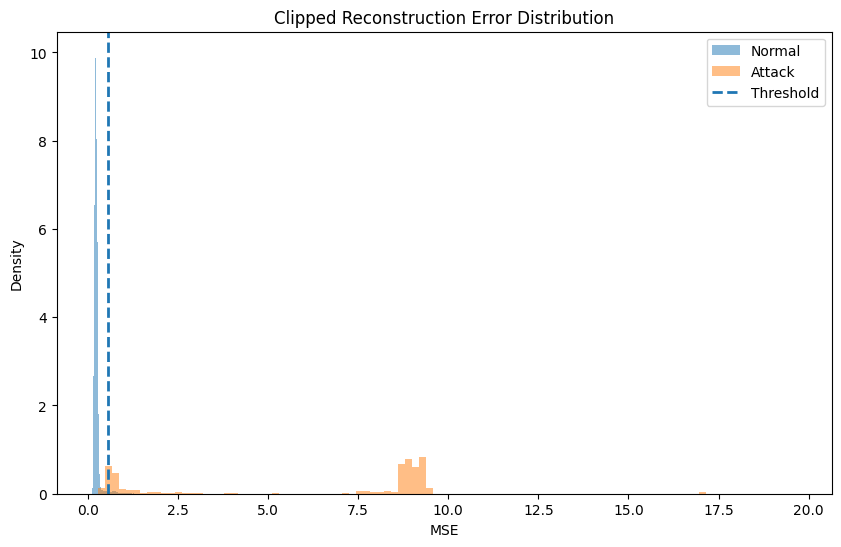

In [71]:
upper = np.percentile(mse, 99)

normal_clip = normal_mse[normal_mse < upper]
attack_clip = attack_mse[attack_mse < upper]

plt.figure(figsize=(10,6))

plt.hist(normal_clip, bins=100, alpha=0.5, density=True, label="Normal")
plt.hist(attack_clip, bins=100, alpha=0.5, density=True, label="Attack")

plt.axvline(threshold, linestyle='--', linewidth=2, label="Threshold")

plt.title("Clipped Reconstruction Error Distribution")
plt.xlabel("MSE")
plt.ylabel("Density")
plt.legend()

plt.show()

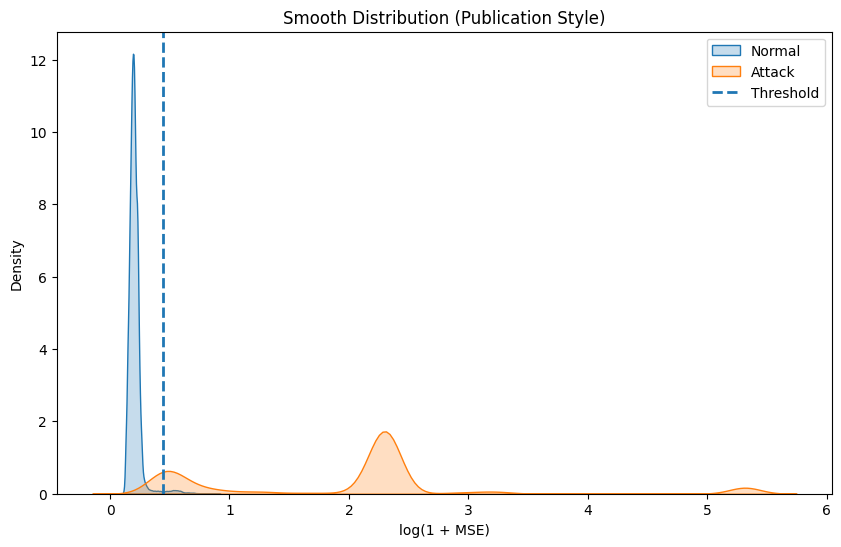

In [72]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.kdeplot(normal_log, label="Normal", fill=True)
sns.kdeplot(attack_log, label="Attack", fill=True)

plt.axvline(threshold_log, linestyle='--', linewidth=2, label="Threshold")

plt.title("Smooth Distribution (Publication Style)")
plt.xlabel("log(1 + MSE)")
plt.ylabel("Density")
plt.legend()

plt.show()

# ROC Curve

In [52]:
fpr, tpr, thresholds = roc_curve(y_test_seq, mse)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

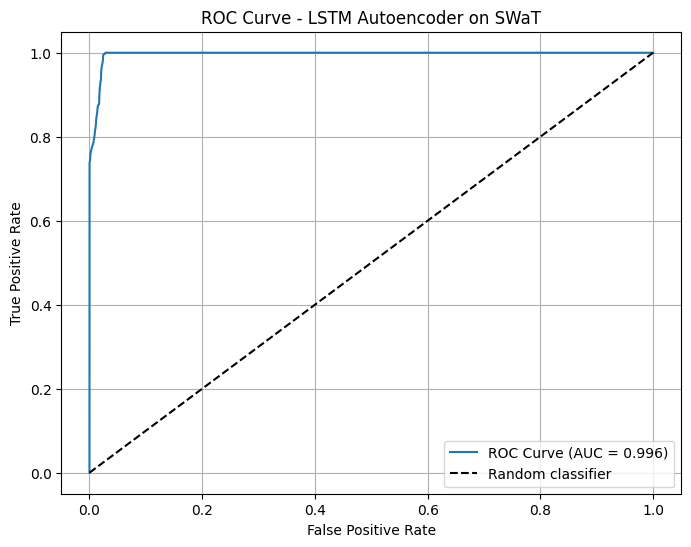

In [53]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc:.3f})")
plt.plot([0,1],[0,1],'k--',label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM Autoencoder on SWaT")
plt.legend()
plt.grid(True)

plt.show()

# **Save the Model**

In [ ]:
lstm_auto.save("lstm_autoencoder_swat_tf", save_format="tf")

In [ ]:
lstm_auto.save("lstm_auto_swat.h5")

In [ ]:
lstm_auto.save_weights('lstm_auto_swat.weights.h5') 

In [ ]:
lstm_auto.save("lstm_auto_swat_complete.keras") 